In [1]:
# ============================================================
# NOTEBOOK 09 — AGENTE DE COBRANZA: MODELADO EWS
# ============================================================
# Propósito  : Entrenar y evaluar el Early Warning System (EWS)
#              usando LightGBM y Regresión Logística.
# Input      : data/processed/df_ews.csv
# Output     : Modelo registrado en MLflow
# Autor      : Marín Serrato Barrios
# Fecha      : Mayo 2026
# ============================================================

# ── Librerías generales ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,       # AUC-ROC: discriminación del modelo
    roc_curve,           # Curva ROC para visualización
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── LightGBM ─────────────────────────────────────────────────
import lightgbm as lgb

# ── SHAP — explicabilidad ────────────────────────────────────
import shap

# ── MLflow — experiment tracking ────────────────────────────
import mlflow
import mlflow.lightgbm
import mlflow.sklearn

# ── Rutas del proyecto ───────────────────────────────────────
BASE  = os.path.abspath('..')
PROC  = os.path.join(BASE, 'data', 'processed')
FIGS  = os.path.join(BASE, 'reports', 'figures')
os.makedirs(FIGS, exist_ok=True)

# ── Configurar MLflow ────────────────────────────────────────
# En Windows, MLflow requiere el prefijo file:/// para rutas locales
# os.path.join genera C:\Users\... que MLflow no reconoce
# La conversión con replace() produce file:///C:/Users/... que sí funciona
MLRUNS_PATH = os.path.join(BASE, 'mlruns').replace('\\', '/')
mlflow.set_tracking_uri(f'file:///{MLRUNS_PATH}')
mlflow.set_experiment('agente_cobranza_ews')

print('✅ Librerías cargadas')
print(f'   Base del proyecto : {BASE}')
print(f'   MLflow tracking   : {os.path.join(BASE, "mlruns")}')
print(f'   Experimento       : agente_cobranza_ews')

✅ Librerías cargadas
   Base del proyecto : C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml
   MLflow tracking   : C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml\mlruns
   Experimento       : agente_cobranza_ews


In [2]:
# ============================================================
# CONFIGURACIÓN CENTRALIZADA DEL MODELADO
# ============================================================
# ⚠️  MODIFICAR AQUÍ — no tocar el código de celdas siguientes
# ============================================================

# ── Parámetros generales ─────────────────────────────────────
RANDOM_SEED  = 42     # Semilla para reproducibilidad
TEST_SIZE    = 0.20   # 20% para prueba, 80% para entrenamiento
N_FOLDS      = 5      # Número de folds para validación cruzada

# ── Target ───────────────────────────────────────────────────
TARGET_COL   = 'TARGET_EWS'   # Columna objetivo del EWS
ID_COL       = 'SK_ID_CURR'   # Identificador del cliente

# ── Columnas a excluir del modelado ──────────────────────────
# Estas columnas NO son features — son identificadores,
# targets o variables que causarían data leakage
COLS_EXCLUIR = [
    'SK_ID_CURR',      # Identificador — no es predictivo
    'TARGET',          # Target original — no usar en EWS
    'TARGET_EWS',      # Target del EWS — es lo que predecimos
]

# ── Parámetros de LightGBM ───────────────────────────────────
# Estos son hiperparámetros base — se pueden optimizar después
LGBM_PARAMS = {
    'objective'       : 'binary',    # Clasificación binaria
    'metric'          : 'auc',       # Optimizar AUC-ROC
    'boosting_type'   : 'gbdt',      # Gradient Boosting clásico
    'n_estimators'    : 500,         # Número de árboles
    'learning_rate'   : 0.05,        # Tasa de aprendizaje
    'max_depth'       : 6,           # Profundidad máxima de árbol
    'num_leaves'      : 31,          # Hojas por árbol
    'min_child_samples': 20,         # Mínimo de muestras por hoja
    'subsample'       : 0.8,         # % de filas por árbol
    'colsample_bytree': 0.8,         # % de columnas por árbol
    'reg_alpha'       : 0.1,         # Regularización L1
    'reg_lambda'      : 0.1,         # Regularización L2
    'random_state'    : RANDOM_SEED,
    'n_jobs'          : -1,          # Usar todos los núcleos
    'verbose'         : -1,          # Sin output durante entrenamiento
}

# ── Parámetros de Regresión Logística ───────────────────────
LR_PARAMS = {
    'C'           : 1.0,        # Inverso de regularización
    'max_iter'    : 1000,       # Máximo de iteraciones
    'random_state': RANDOM_SEED,
    'n_jobs'      : -1,
}

# ── Umbral de decisión ───────────────────────────────────────
# Probabilidad a partir de la cual se clasifica como mora
# 0.2 es el default — se puede ajustar según el negocio
# Un umbral más bajo → más alertas → más recall → menos precisión
# Un umbral más alto → menos alertas → menos recall → más precisión
UMBRAL_DECISION = 0.20

# ── Gate de calidad ──────────────────────────────────────────
# El modelo solo se registra en MLflow si supera este AUC
# Mismo criterio que el Agente de Originación
AUC_MINIMO = 0.70   # EWS es más difícil → umbral más flexible

print('✅ Configuración del modelado cargada')
print(f'   Target            : {TARGET_COL}')
print(f'   Split train/test  : {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}')
print(f'   Folds CV          : {N_FOLDS}')
print(f'   AUC mínimo (gate) : {AUC_MINIMO}')
print(f'   Umbral decisión   : {UMBRAL_DECISION}')

# ── Diccionario de nombres legibles ──────────────────────────
# Usado en visualizaciones, SHAP y dashboard
# El modelo entrena con nombres técnicos para evitar errores
# con caracteres especiales en scikit-learn y LightGBM
NOMBRES_LEGIBLES = {
    # ── Perfil del cliente ────────────────────────────────
    'NAME_CONTRACT_TYPE'       : 'Tipo de contrato',
    'CODE_GENDER'              : 'Género',
    'FLAG_OWN_CAR'             : 'Tiene auto',
    'FLAG_OWN_REALTY'          : 'Tiene propiedad',
    'CNT_CHILDREN'             : 'Número de hijos',
    'AMT_INCOME_TOTAL'         : 'Ingreso anual',
    'AMT_CREDIT'               : 'Monto del crédito',
    'AMT_ANNUITY'              : 'Cuota mensual',
    'AMT_GOODS_PRICE'          : 'Precio del bien',
    'NAME_INCOME_TYPE'         : 'Tipo de ingreso',
    'NAME_EDUCATION_TYPE'      : 'Nivel educativo',
    'NAME_FAMILY_STATUS'       : 'Estado civil',
    'REGION_POPULATION_RELATIVE': 'Densidad de región',
    'DAYS_BIRTH'               : 'Edad (días)',
    'DAYS_EMPLOYED'            : 'Antigüedad laboral (días)',
    'DAYS_REGISTRATION'        : 'Días desde registro',
    'CNT_FAM_MEMBERS'          : 'Miembros del hogar',
    'REGION_RATING_CLIENT'     : 'Rating de la región',

    # ── Comportamiento de pago (installments) ────────────
    'max_dias_atraso'          : 'Máx. días de atraso',
    'mean_dias_atraso'         : 'Promedio días de atraso',
    'std_dias_atraso'          : 'Variabilidad del atraso',
    'pct_cuotas_atrasadas'     : '% cuotas atrasadas',
    'pct_cuotas_30dias'        : '% cuotas con +30 días',
    'pct_cuotas_60dias'        : '% cuotas con +60 días',
    'pct_cuotas_90dias'        : '% cuotas con +90 días',
    'pct_pagos_parciales'      : '% pagos parciales',
    'pct_pagos_completos'      : '% pagos completos',
    'n_cuotas_en_mora'         : 'N° cuotas en mora',
    'pct_cuotas_en_mora'       : '% cuotas en mora',
    'n_cuotas_total'           : 'Total de cuotas',
    'n_cuotas_recientes'       : 'Cuotas último año',

    # ── Comportamiento mensual (POS_CASH) ─────────────────
    'max_dpd'                  : 'Máx. DPD mensual',
    'max_dpd_def'              : 'Máx. DPD regulatorio',
    'mean_dpd'                 : 'Promedio DPD mensual',
    'mean_dpd_def'             : 'Promedio DPD regulatorio',
    'pct_meses_dpd'            : '% meses con DPD',
    'pct_meses_dpd30'          : '% meses con DPD 30+',
    'n_meses_activo'           : 'Meses de crédito activo',

    # ── Historial de solicitudes previas ─────────────────
    'n_solicitudes_previas'    : 'N° solicitudes previas',
    'n_aprobadas_previas'      : 'N° créditos aprobados prev.',
    'n_rechazadas_previas'     : 'N° créditos rechazados prev.',
    'n_canceladas_previas'     : 'N° créditos cancelados prev.',
    'amt_credito_prev_max'     : 'Monto máx. crédito previo',
    'amt_credito_prev_mean'    : 'Monto prom. crédito previo',
    'amt_aplicacion_prev_mean' : 'Monto prom. solicitud previa',
    'dias_ultima_solicitud'    : 'Días desde última solicitud',
    'tasa_aprobacion_historica': 'Tasa aprobación histórica',
    'es_cliente_recurrente'    : 'Cliente recurrente',

    # ── Variables derivadas ───────────────────────────────
    'plazo_meses'              : 'Plazo del crédito (meses)',
    'carga_financiera'         : 'Carga financiera (cuota/ingreso)',
    'edad_anos'                : 'Edad (años)',
    'antiguedad_laboral_anos'  : 'Antigüedad laboral (años)',
}

print(f"   Diccionario de nombres legibles: "
      f"{len(NOMBRES_LEGIBLES)} variables mapeadas")

✅ Configuración del modelado cargada
   Target            : TARGET_EWS
   Split train/test  : 80/20
   Folds CV          : 5
   AUC mínimo (gate) : 0.7
   Umbral decisión   : 0.2
   Diccionario de nombres legibles: 52 variables mapeadas


In [3]:
# ============================================================
# CARGA Y PREPARACIÓN DE DATOS
# ============================================================
# Cargamos df_ews.csv — el dataset construido en el notebook
# 08 con 234,620 clientes y 55 features.
# ============================================================

print("Cargando dataset EWS...")

df = pd.read_csv(f'{PROC}/df_ews.csv')

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} cols")
print(f"   Distribución TARGET_EWS:")
print(f"   Sin mora (0): {(df[TARGET_COL]==0).sum():>8,} "
      f"({(df[TARGET_COL]==0).mean():.1%})")
print(f"   Con mora (1): {(df[TARGET_COL]==1).sum():>8,} "
      f"({(df[TARGET_COL]==1).mean():.1%})")

# ── Identificar columnas categóricas ─────────────────────────
# Las columnas de texto necesitan ser convertidas a números
# antes de que el modelo pueda usarlas
cols_categoricas = df.select_dtypes(
    include=['object']
).columns.tolist()

print(f"\n📊 Columnas categóricas encontradas ({len(cols_categoricas)}):")
for col in cols_categoricas:
    n_categorias = df[col].nunique()
    print(f"   {col:<30} → {n_categorias} categorías")

# ── Encodear variables categóricas ───────────────────────────
# LabelEncoder convierte texto a números
# Ejemplo: 'Cash loans' → 0, 'Revolving loans' → 1
# Guardamos los encoders para poder decodificar después

encoders = {}   # Diccionario para guardar un encoder por columna

for col in cols_categoricas:
    le = LabelEncoder()
    # fillna('MISSING') maneja nulos antes de encodear
    df[col] = le.fit_transform(
        df[col].fillna('MISSING').astype(str)
    )
    encoders[col] = le

print(f"\n✅ Variables categóricas encodeadas")

# ── Separar features y target ────────────────────────────────
# X = todas las columnas excepto las que definimos en COLS_EXCLUIR
# y = solo el TARGET_EWS

# Columnas que realmente existen en el dataset para excluir
cols_excluir_existentes = [
    c for c in COLS_EXCLUIR if c in df.columns
]

X = df.drop(columns=cols_excluir_existentes)
y = df[TARGET_COL]

print(f"\n✅ Features y target separados:")
print(f"   X (features) : {X.shape[0]:,} filas × {X.shape[1]} cols")
print(f"   y (target)   : {y.shape[0]:,} valores")
print(f"   Features disponibles:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:>3}. {col}")

Cargando dataset EWS...
✅ Dataset cargado: 234,620 filas × 55 cols
   Distribución TARGET_EWS:
   Sin mora (0):  183,085 (78.0%)
   Con mora (1):   51,535 (22.0%)

📊 Columnas categóricas encontradas (7):
   NAME_CONTRACT_TYPE             → 2 categorías
   CODE_GENDER                    → 3 categorías
   FLAG_OWN_CAR                   → 2 categorías
   FLAG_OWN_REALTY                → 2 categorías
   NAME_INCOME_TYPE               → 7 categorías
   NAME_EDUCATION_TYPE            → 5 categorías
   NAME_FAMILY_STATUS             → 5 categorías

✅ Variables categóricas encodeadas

✅ Features y target separados:
   X (features) : 234,620 filas × 52 cols
   y (target)   : 234,620 valores
   Features disponibles:
     1. NAME_CONTRACT_TYPE
     2. CODE_GENDER
     3. FLAG_OWN_CAR
     4. FLAG_OWN_REALTY
     5. CNT_CHILDREN
     6. AMT_INCOME_TOTAL
     7. AMT_CREDIT
     8. AMT_ANNUITY
     9. AMT_GOODS_PRICE
    10. NAME_INCOME_TYPE
    11. NAME_EDUCATION_TYPE
    12. NAME_FAMILY_STATUS
   

In [4]:
# ============================================================
# CELDA 4 — SPLIT TRAIN/TEST Y ANÁLISIS DE NULOS
# ============================================================
# Objetivo: dividir el dataset en entrenamiento y prueba,
# e identificar cómo tratar los valores nulos.
#
# ¿Por qué StratifiedKFold y stratify=y?
# Con TARGET desbalanceado (78%/22%), un split aleatorio
# podría concentrar todos los casos de mora en train o test.
# stratify=y garantiza que ambos conjuntos tengan la misma
# proporción de mora que el dataset completo.
# ============================================================

# ── Split train/test ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = y    # Mantener proporción de mora en ambos sets
)

print("✅ Split train/test completado:")
print(f"   Train: {X_train.shape[0]:>8,} filas "
      f"({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test : {X_test.shape[0]:>8,} filas "
      f"({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Distribución TARGET en train:")
print(f"   Sin mora (0): {(y_train==0).sum():>7,} "
      f"({(y_train==0).mean():.1%})")
print(f"   Con mora (1): {(y_train==1).sum():>7,} "
      f"({(y_train==1).mean():.1%})")
print(f"\n   Distribución TARGET en test:")
print(f"   Sin mora (0): {(y_test==0).sum():>7,} "
      f"({(y_test==0).mean():.1%})")
print(f"   Con mora (1): {(y_test==1).sum():>7,} "
      f"({(y_test==1).mean():.1%})")

# ── Análisis de nulos en el conjunto de entrenamiento ────────
print(f"\n📊 Variables con valores nulos en train:")
print(f"{'Variable':<35} {'Nulos':>8} {'%':>8}")
print("-" * 55)

nulos_train = X_train.isnull().sum()
nulos_pct   = (nulos_train / len(X_train) * 100).round(1)
nulos_df    = pd.DataFrame({
    'nulos': nulos_train,
    'pct'  : nulos_pct
}).query('nulos > 0').sort_values('pct', ascending=False)

if len(nulos_df) == 0:
    print("   Sin valores nulos — dataset limpio")
else:
    for col, row in nulos_df.iterrows():
        print(f"   {col:<33} {row['nulos']:>8,} {row['pct']:>7.1f}%")

print(f"\n   Total columnas con nulos: {len(nulos_df)}")
print(f"   Total columnas sin nulos: "
      f"{X_train.shape[1] - len(nulos_df)}")

✅ Split train/test completado:
   Train:  187,696 filas (80.0%)
   Test :   46,924 filas (20.0%)

   Distribución TARGET en train:
   Sin mora (0): 146,468 (78.0%)
   Con mora (1):  41,228 (22.0%)

   Distribución TARGET en test:
   Sin mora (0):  36,617 (78.0%)
   Con mora (1):  10,307 (22.0%)

📊 Variables con valores nulos en train:
Variable                               Nulos        %
-------------------------------------------------------
   max_dpd                            1,954.0     1.0%
   mean_dpd                           1,954.0     1.0%
   max_dpd_def                        1,954.0     1.0%
   pct_meses_dpd                      1,954.0     1.0%
   mean_dpd_def                       1,954.0     1.0%
   pct_meses_dpd30                    1,954.0     1.0%
   n_meses_activo                     1,954.0     1.0%
   amt_credito_prev_max                 583.0     0.3%
   amt_credito_prev_mean                583.0     0.3%
   n_solicitudes_previas                583.0     0.3%
   

In [5]:
# ============================================================
# CELDA 5 — IMPUTACIÓN DE VALORES NULOS
# ============================================================
# Objetivo: tratar los valores nulos antes de entrenar.
#
# Estrategia por tipo de nulo:
# ┌─────────────────────────────────────────────────────────┐
# │ Variables POS_CASH sin registro  → imputar con 0        │
# │ Variables de historial previo    → imputar con 0        │
# │ Variables continuas con pocos    → imputar con mediana  │
# │  nulos (AMT_GOODS_PRICE, etc.)                          │
# └─────────────────────────────────────────────────────────┘
#
# IMPORTANTE: calculamos medianas SOLO en train para evitar
# data leakage — si usáramos medianas del dataset completo
# estaríamos usando información del test para transformar
# el train.
# ============================================================

# ── Variables que se imputan con 0 ───────────────────────────

# Variables de POS_CASH: ausencia de registro = sin atraso
VARS_IMPUTAR_CERO_POS = [
    'max_dpd', 'mean_dpd', 'max_dpd_def',
    'mean_dpd_def', 'pct_meses_dpd',
    'pct_meses_dpd30', 'n_meses_activo'
]

# Variables de historial previo: sin registro = cliente nuevo
VARS_IMPUTAR_CERO_PREV = [
    'n_solicitudes_previas', 'n_aprobadas_previas',
    'n_rechazadas_previas',  'n_canceladas_previas',
    'amt_credito_prev_max',  'amt_credito_prev_mean',
    'amt_aplicacion_prev_mean', 'dias_ultima_solicitud',
    'tasa_aprobacion_historica', 'es_cliente_recurrente'
]

VARS_IMPUTAR_CERO = VARS_IMPUTAR_CERO_POS + VARS_IMPUTAR_CERO_PREV

# ── Variables que se imputan con mediana ─────────────────────
# Calculamos medianas SOLO en train — no en el dataset completo
# Esto evita data leakage: el test no influye en la transformación
VARS_IMPUTAR_MEDIANA = [
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'plazo_meses',
    'carga_financiera'
]

# Calcular medianas en train
medianas = X_train[VARS_IMPUTAR_MEDIANA].median()

print("📊 Medianas calculadas en train (para imputación):")
for col, val in medianas.items():
    print(f"   {col:<25} : {val:>10.2f}")

# ── Aplicar imputación a train y test ────────────────────────
# Aplicamos exactamente la misma transformación a ambos
# conjuntos usando los valores calculados en train

# Imputar con 0
for col in VARS_IMPUTAR_CERO:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_test[col]  = X_test[col].fillna(0)

# Imputar con medianas de train
for col in VARS_IMPUTAR_MEDIANA:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(medianas[col])
        X_test[col]  = X_test[col].fillna(medianas[col])

# ── Verificar que no quedan nulos ────────────────────────────
nulos_restantes_train = X_train.isnull().sum().sum()
nulos_restantes_test  = X_test.isnull().sum().sum()

print(f"\n✅ Imputación completada:")
print(f"   Variables imputadas con 0       : "
      f"{len(VARS_IMPUTAR_CERO)}")
print(f"   Variables imputadas con mediana : "
      f"{len(VARS_IMPUTAR_MEDIANA)}")
print(f"   Nulos restantes en train        : "
      f"{nulos_restantes_train}")
print(f"   Nulos restantes en test         : "
      f"{nulos_restantes_test}")

if nulos_restantes_train == 0 and nulos_restantes_test == 0:
    print(f"\n✅ Dataset listo para modelado — sin valores nulos")
else:
    print(f"\n⚠️  Aún quedan nulos — revisar antes de continuar")

📊 Medianas calculadas en train (para imputación):
   AMT_GOODS_PRICE           :  450000.00
   AMT_ANNUITY               :   24939.00
   plazo_meses               :      20.00
   carga_financiera          :       1.95

✅ Imputación completada:
   Variables imputadas con 0       : 17
   Variables imputadas con mediana : 4
   Nulos restantes en train        : 0
   Nulos restantes en test         : 0

✅ Dataset listo para modelado — sin valores nulos


In [6]:
# ============================================================
# CELDA 6 — ENTRENAMIENTO LIGHTGBM CON VALIDACIÓN CRUZADA
# ============================================================
# Objetivo: entrenar LightGBM con 5-fold cross validation
# y registrar el experimento en MLflow.
#
# Flujo:
# 1. Validación cruzada → AUC promedio confiable
# 2. Entrenamiento final → modelo con todos los datos train
# 3. Evaluación en test → métricas finales
# 4. Registro en MLflow → si supera el gate AUC_MINIMO
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import time

print("=" * 55)
print("ENTRENAMIENTO LIGHTGBM — EARLY WARNING SYSTEM")
print("=" * 55)

# ── Paso 1: Validación cruzada ────────────────────────────────
# StratifiedKFold garantiza que cada fold tenga la misma
# proporción de mora que el dataset completo
print(f"\n[1/4] Validación cruzada {N_FOLDS} folds...")

skf     = StratifiedKFold(
    n_splits  = N_FOLDS,
    shuffle   = True,
    random_state = RANDOM_SEED
)
auc_folds = []   # AUC de cada fold

for fold, (idx_train, idx_val) in enumerate(
    skf.split(X_train, y_train), 1
):
    # Separar datos del fold
    X_fold_train = X_train.iloc[idx_train]
    X_fold_val   = X_train.iloc[idx_val]
    y_fold_train = y_train.iloc[idx_train]
    y_fold_val   = y_train.iloc[idx_val]

    # Entrenar modelo del fold
    modelo_fold = lgb.LGBMClassifier(**LGBM_PARAMS)
    modelo_fold.fit(
        X_fold_train, y_fold_train,
        eval_set = [(X_fold_val, y_fold_val)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)]
    )

    # Evaluar en validación del fold
    y_pred_fold = modelo_fold.predict_proba(
        X_fold_val
    )[:, 1]
    auc_fold = roc_auc_score(y_fold_val, y_pred_fold)
    auc_folds.append(auc_fold)

    print(f"   Fold {fold}: AUC = {auc_fold:.4f}")

auc_cv_mean = np.mean(auc_folds)
auc_cv_std  = np.std(auc_folds)

print(f"\n   AUC CV promedio : {auc_cv_mean:.4f}")
print(f"   AUC CV std      : {auc_cv_std:.4f}")
print(f"   Rango           : "
      f"{auc_cv_mean - auc_cv_std:.4f} — "
      f"{auc_cv_mean + auc_cv_std:.4f}")

# ── Paso 2: Entrenamiento final ───────────────────────────────
# Entrenamos con todos los datos de train (no solo 4/5)
# Este es el modelo que usaremos para predecir
print(f"\n[2/4] Entrenamiento final con todos los datos train...")
inicio = time.time()

modelo_lgbm = lgb.LGBMClassifier(**LGBM_PARAMS)
modelo_lgbm.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(period=-1)]
)

tiempo_entrenamiento = time.time() - inicio
print(f"   ✅ Entrenamiento completado en "
      f"{tiempo_entrenamiento:.1f} segundos")
print(f"   Árboles entrenados: "
      f"{modelo_lgbm.best_iteration_}")

# ── Paso 3: Evaluación en test ────────────────────────────────
print(f"\n[3/4] Evaluando en test set...")

# Probabilidades predichas (columna 1 = probabilidad de mora)
y_pred_proba = modelo_lgbm.predict_proba(X_test)[:, 1]

# Clasificación binaria según umbral de configuración
y_pred_clase = (y_pred_proba >= UMBRAL_DECISION).astype(int)

# Métricas
auc_test  = roc_auc_score(y_test, y_pred_proba)
recall    = recall_score(y_test, y_pred_clase)
precision = precision_score(y_test, y_pred_clase)
f1        = f1_score(y_test, y_pred_clase)

# KS — Kolmogorov-Smirnov
# Mide la separación máxima entre la distribución de
# buenos y malos pagadores — estándar en la industria
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ks_stat     = np.max(tpr - fpr)

print(f"\n   📊 Métricas en test set:")
print(f"   {'Métrica':<25} {'Valor':>10}")
print(f"   {'-'*37}")
print(f"   {'AUC-ROC':<25} {auc_test:>10.4f}")
print(f"   {'KS Statistic':<25} {ks_stat:>10.4f}")
print(f"   {'Recall (Sensibilidad)':<25} {recall:>10.4f}")
print(f"   {'Precisión':<25} {precision:>10.4f}")
print(f"   {'F1-Score':<25} {f1:>10.4f}")
print(f"   {'AUC CV (validación)':<25} {auc_cv_mean:>10.4f}")

# ── Paso 4: Registrar en MLflow ───────────────────────────────
print(f"\n[4/4] Registrando en MLflow...")

# Verificar gate de calidad
if auc_test >= AUC_MINIMO:
    print(f"   ✅ Gate superado: AUC {auc_test:.4f} ≥ {AUC_MINIMO}")

    with mlflow.start_run(run_name='lightgbm_ews_v1'):

        # Registrar parámetros del modelo
        mlflow.log_params(LGBM_PARAMS)
        mlflow.log_param('test_size',    TEST_SIZE)
        mlflow.log_param('n_folds',      N_FOLDS)
        mlflow.log_param('umbral_mora_dias', 5)
        mlflow.log_param('ventana_prediccion', 90)

        # Registrar métricas
        mlflow.log_metric('auc_test',     auc_test)
        mlflow.log_metric('ks_stat',      ks_stat)
        mlflow.log_metric('recall',       recall)
        mlflow.log_metric('precision',    precision)
        mlflow.log_metric('f1',           f1)
        mlflow.log_metric('auc_cv_mean',  auc_cv_mean)
        mlflow.log_metric('auc_cv_std',   auc_cv_std)
        mlflow.log_metric('n_arboles',
                          modelo_lgbm.best_iteration_)

        # Registrar el modelo
        mlflow.lightgbm.log_model(
            modelo_lgbm,
            artifact_path   = 'lightgbm_ews',
            registered_model_name = 'lightgbm_ews'
        )

    print(f"   ✅ Modelo registrado en MLflow: lightgbm_ews")

else:
    print(f"   ❌ Gate NO superado: "
          f"AUC {auc_test:.4f} < {AUC_MINIMO}")
    print(f"   Modelo no registrado — revisar features o parámetros")

ENTRENAMIENTO LIGHTGBM — EARLY WARNING SYSTEM

[1/4] Validación cruzada 5 folds...
   Fold 1: AUC = 0.8654
   Fold 2: AUC = 0.8665
   Fold 3: AUC = 0.8690
   Fold 4: AUC = 0.8708
   Fold 5: AUC = 0.8697

   AUC CV promedio : 0.8683
   AUC CV std      : 0.0020
   Rango           : 0.8663 — 0.8703

[2/4] Entrenamiento final con todos los datos train...
   ✅ Entrenamiento completado en 29.8 segundos
   Árboles entrenados: 500

[3/4] Evaluando en test set...

   📊 Métricas en test set:
   Métrica                        Valor
   -------------------------------------
   AUC-ROC                       0.8712
   KS Statistic                  0.5719
   Recall (Sensibilidad)         0.7957
   Precisión                     0.4969
   F1-Score                      0.6118
   AUC CV (validación)           0.8683

[4/4] Registrando en MLflow...
   ✅ Gate superado: AUC 0.8712 ≥ 0.7


2026/05/18 11:35:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 11:36:01 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'lightgbm_ews' already exists. Creating a new version of this model...
Created version '5' of model 'lightgbm_ews'.


   ✅ Modelo registrado en MLflow: lightgbm_ews


ANÁLISIS DE UMBRAL DE DECISIÓN

  Umbral     Recall    Precisión       F1    N alertas    % cartera
-----------------------------------------------------------------
    0.10      90.7%        37.9%   0.5347     24,670       52.6%
    0.15      85.0%        44.3%   0.5821     19,796       42.2%
    0.20      79.6%        49.7%   0.6118     16,504       35.2% ← actual
    0.25      74.2%        54.7%   0.6296     13,990       29.8%
    0.30      69.1%        59.5%   0.6394     11,972       25.5%
    0.35      64.0%        64.2%   0.6411     10,270       21.9%
    0.40      59.0%        68.3%   0.6334      8,907       19.0%
    0.45      54.2%        72.8%   0.6211      7,668       16.3%
    0.50      49.1%        76.5%   0.5986      6,617       14.1%
    0.55      44.4%        80.5%   0.5727      5,687       12.1%
    0.60      39.8%        83.8%   0.5399      4,896       10.4%
    0.65      35.2%        86.9%   0.5013      4,176        8.9%
    0.70      31.1%        90.0%   0.4619    

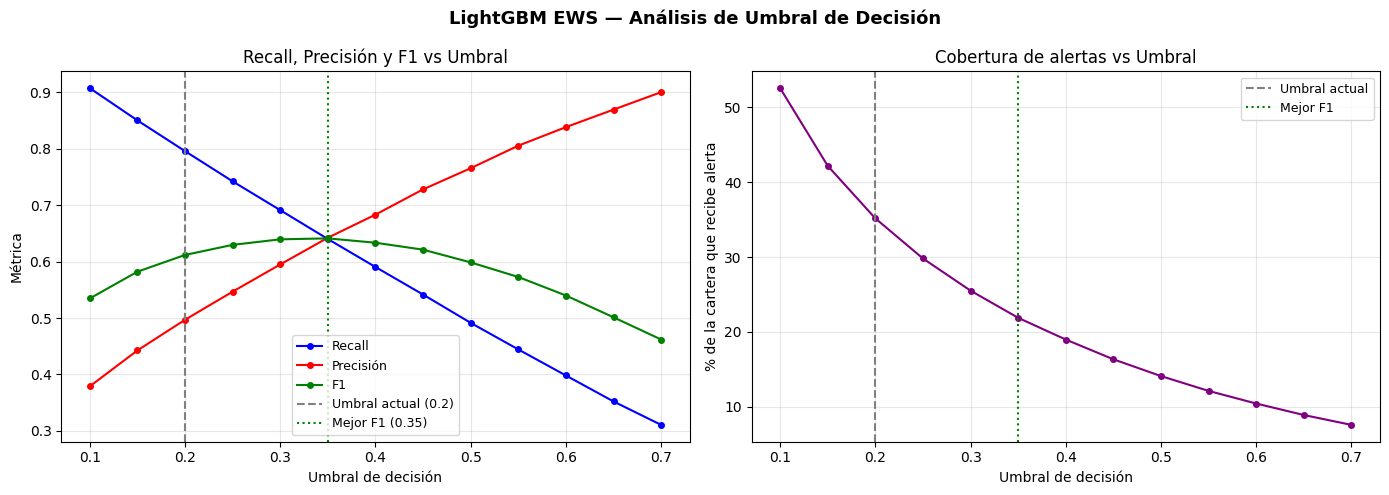

✅ Gráfica guardada


In [7]:
# ============================================================
# CELDA 7 — ANÁLISIS DEL UMBRAL DE DECISIÓN
# ============================================================
# Objetivo: encontrar el umbral óptimo de clasificación.
#
# El umbral por default es 0.50 pero en cobranza es común
# usar umbrales más bajos (0.30-0.40) para detectar más
# clientes en riesgo aunque haya más falsas alarmas.
#
# Trade-off fundamental:
# Umbral bajo → más alertas → más recall → más carga operativa
# Umbral alto → menos alertas → menos recall → menos carga
#
# La decisión es del negocio, no del modelo.
# ============================================================

print("=" * 55)
print("ANÁLISIS DE UMBRAL DE DECISIÓN")
print("=" * 55)
print(f"\n{'Umbral':>8} {'Recall':>10} {'Precisión':>12} "
      f"{'F1':>8} {'N alertas':>12} {'% cartera':>12}")
print("-" * 65)

umbrales     = np.arange(0.10, 0.71, 0.05)
resultados_u = []

for u in umbrales:
    y_pred_u  = (y_pred_proba >= u).astype(int)
    rec       = recall_score(y_test, y_pred_u)
    prec      = precision_score(y_test, y_pred_u,
                                zero_division=0)
    f1_u      = f1_score(y_test, y_pred_u,
                         zero_division=0)
    n_alertas = y_pred_u.sum()
    pct_cart  = n_alertas / len(y_test)

    resultados_u.append({
        'umbral'   : u,
        'recall'   : rec,
        'precision': prec,
        'f1'       : f1_u,
        'n_alertas': n_alertas,
        'pct_cart' : pct_cart
    })

    # Marcar el umbral actual de configuración
    marca = " ← actual" if abs(u - UMBRAL_DECISION) < 0.01 else ""
    print(f"   {u:>5.2f}   {rec:>8.1%}   {prec:>10.1%}   "
          f"{f1_u:>6.4f}   {n_alertas:>8,}   "
          f"{pct_cart:>9.1%}{marca}")

df_umbrales = pd.DataFrame(resultados_u)

# ── Umbral óptimo por F1 ─────────────────────────────────────
# F1 balancea Recall y Precisión — el umbral con mayor F1
# es el mejor balance matemático entre ambas métricas
idx_mejor_f1  = df_umbrales['f1'].idxmax()
umbral_opt_f1 = df_umbrales.loc[idx_mejor_f1, 'umbral']

# ── Umbral óptimo por Recall mínimo 70% ─────────────────────
# En cobranza a veces se define un Recall mínimo aceptable
# y se elige el umbral con mejor Precisión dado ese recall
df_recall70   = df_umbrales[df_umbrales['recall'] >= 0.70]
if len(df_recall70) > 0:
    idx_prec_max  = df_recall70['precision'].idxmax()
    umbral_opt_r70 = df_recall70.loc[idx_prec_max, 'umbral']
else:
    umbral_opt_r70 = None

print(f"\n📊 Umbrales recomendados:")
print(f"   Mejor F1 (balance matemático) : "
      f"{umbral_opt_f1:.2f} "
      f"(F1={df_umbrales.loc[idx_mejor_f1,'f1']:.4f})")
if umbral_opt_r70:
    print(f"   Mejor Precisión con Recall≥70%: "
          f"{umbral_opt_r70:.2f} "
          f"(Recall={df_recall70.loc[idx_prec_max,'recall']:.1%}, "
          f"Precisión={df_recall70.loc[idx_prec_max,'precision']:.1%})")

# ── Visualización ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM EWS — Análisis de Umbral de Decisión',
             fontsize=13, fontweight='bold')

# Gráfica 1: Recall y Precisión vs Umbral
ax1 = axes[0]
ax1.plot(df_umbrales['umbral'], df_umbrales['recall'],
         'b-o', markersize=4, label='Recall')
ax1.plot(df_umbrales['umbral'], df_umbrales['precision'],
         'r-o', markersize=4, label='Precisión')
ax1.plot(df_umbrales['umbral'], df_umbrales['f1'],
         'g-o', markersize=4, label='F1')
ax1.axvline(x=UMBRAL_DECISION, color='gray',
            linestyle='--', label=f'Umbral actual ({UMBRAL_DECISION})')
ax1.axvline(x=umbral_opt_f1, color='green',
            linestyle=':', label=f'Mejor F1 ({umbral_opt_f1:.2f})')
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Métrica')
ax1.set_title('Recall, Precisión y F1 vs Umbral')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Número de alertas vs Umbral
ax2 = axes[1]
ax2.plot(df_umbrales['umbral'],
         df_umbrales['pct_cart'] * 100,
         'purple', marker='o', markersize=4)
ax2.axvline(x=UMBRAL_DECISION, color='gray',
            linestyle='--', label=f'Umbral actual')
ax2.axvline(x=umbral_opt_f1, color='green',
            linestyle=':', label=f'Mejor F1')
ax2.set_xlabel('Umbral de decisión')
ax2.set_ylabel('% de la cartera que recibe alerta')
ax2.set_title('Cobertura de alertas vs Umbral')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGS}/ews_umbral_analisis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

ANÁLISIS COSTO-BENEFICIO DEL UMBRAL DE DECISIÓN

Parámetros de costo:
   Costo por gestión (falsa alarma)  : $       100 MXN
   Pérdida por mora no detectada     : $    89,854 MXN
   Ratio costo mora/gestión          :        899x

  Umbral       FP       FN      C.Gestión         C.Mora    Costo Total   Recall
--------------------------------------------------------------------------------
    0.10   15,319      956   $  1,531,900   $ 85,900,424   $ 87,432,324    90.7%
    0.15   11,034    1,545   $  1,103,400   $138,824,430   $139,927,830    85.0%
    0.20    8,303    2,106   $    830,300   $189,232,524   $190,062,824    79.6% ← actual
    0.25    6,341    2,658   $    634,100   $238,831,932   $239,466,032    74.2%
    0.30    4,849    3,184   $    484,900   $286,095,136   $286,580,036    69.1%
    0.35    3,674    3,711   $    367,400   $333,448,194   $333,815,594    64.0%
    0.40    2,822    4,222   $    282,200   $379,363,588   $379,645,788    59.0%
    0.45    2,086    4,725   $

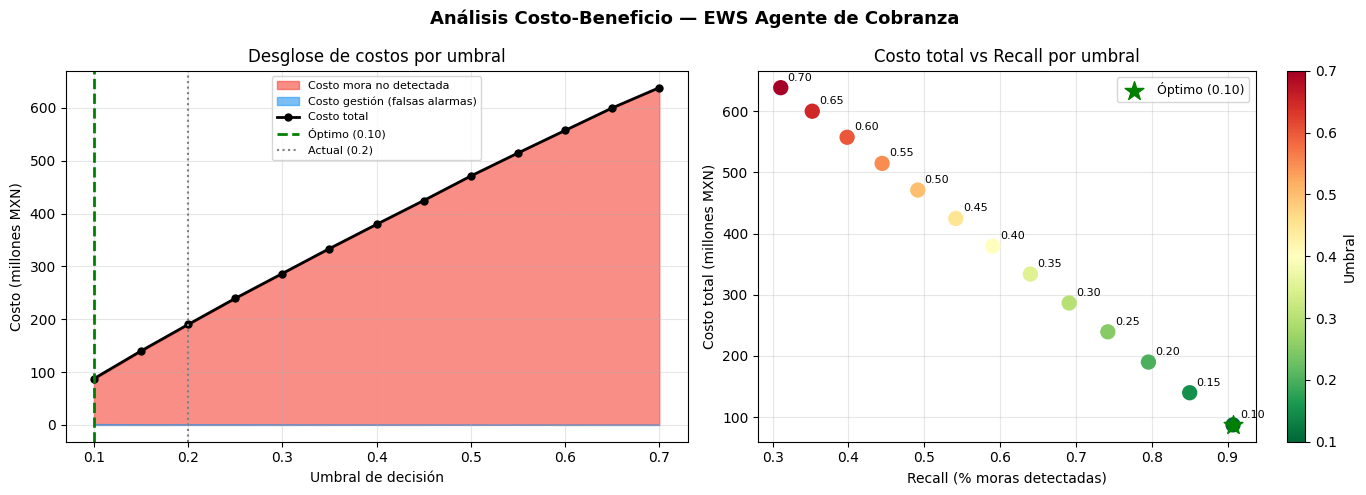

✅ Gráfica guardada


In [8]:
# ============================================================
# CELDA 8 — ANÁLISIS COSTO-BENEFICIO DEL UMBRAL
# ============================================================
# Objetivo: encontrar el umbral que minimiza el costo
# económico total considerando:
#
# COSTO 1 — Falsa alarma (False Positive):
#   Llamamos a un cliente que iba a pagar bien
#   → Costo de gestión innecesaria
#
# COSTO 2 — Mora no detectada (False Negative):
#   No llamamos a un cliente que cae en mora
#   → Pérdida crediticia real
#
# Costo total = FP × C_gestion + FN × C_mora
#
# Fuente de estimaciones:
# - C_gestion: estándar industria microfinanzas MX
#   ($80-150 MXN por contacto, usamos $100)
# - C_mora: 15% del monto promedio del crédito del dataset
#   ($599,026 × 15% = $89,854 MXN por crédito perdido)
# ============================================================

# ── Parámetros de costo ──────────────────────────────────────
# Modifica estos valores según la realidad de tu institución
C_GESTION = 100       # MXN por contacto de cobranza preventiva
C_MORA    = 89_854    # MXN de pérdida promedio por mora no detectada

print("=" * 60)
print("ANÁLISIS COSTO-BENEFICIO DEL UMBRAL DE DECISIÓN")
print("=" * 60)
print(f"\nParámetros de costo:")
print(f"   Costo por gestión (falsa alarma)  : "
      f"${C_GESTION:>10,.0f} MXN")
print(f"   Pérdida por mora no detectada     : "
      f"${C_MORA:>10,.0f} MXN")
print(f"   Ratio costo mora/gestión          : "
      f"{C_MORA/C_GESTION:>10.0f}x")

# ── Calcular costo por umbral ────────────────────────────────
print(f"\n{'Umbral':>8} {'FP':>8} {'FN':>8} "
      f"{'C.Gestión':>14} {'C.Mora':>14} "
      f"{'Costo Total':>14} {'Recall':>8}")
print("-" * 80)

costos = []

for u in np.arange(0.10, 0.71, 0.05):
    y_pred_u = (y_pred_proba >= u).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred_u
    ).ravel()

    # Costos
    costo_gestion = fp * C_GESTION
    costo_mora    = fn * C_MORA
    costo_total   = costo_gestion + costo_mora
    recall_u      = tp / (tp + fn) if (tp + fn) > 0 else 0

    costos.append({
        'umbral'        : u,
        'fp'            : fp,
        'fn'            : fn,
        'costo_gestion' : costo_gestion,
        'costo_mora'    : costo_mora,
        'costo_total'   : costo_total,
        'recall'        : recall_u
    })

    marca = " ← actual" if abs(u - UMBRAL_DECISION) < 0.01 else ""
    print(f"   {u:>5.2f}   {fp:>6,}   {fn:>6,}   "
          f"${costo_gestion:>11,.0f}   "
          f"${costo_mora:>11,.0f}   "
          f"${costo_total:>11,.0f}   "
          f"{recall_u:>6.1%}{marca}")

df_costos = pd.DataFrame(costos)

# ── Umbral óptimo económico ──────────────────────────────────
idx_opt    = df_costos['costo_total'].idxmin()
umbral_opt = df_costos.loc[idx_opt, 'umbral']
costo_opt  = df_costos.loc[idx_opt, 'costo_total']
recall_opt = df_costos.loc[idx_opt, 'recall']

print(f"\n{'='*60}")
print(f"UMBRAL ÓPTIMO ECONÓMICO: {umbral_opt:.2f}")
print(f"{'='*60}")
print(f"   Costo total mínimo : ${costo_opt:>14,.0f} MXN")
print(f"   Recall             : {recall_opt:.1%}")
print(f"   Falsas alarmas     : "
      f"{df_costos.loc[idx_opt,'fp']:>8,}")
print(f"   Moras no detectadas: "
      f"{df_costos.loc[idx_opt,'fn']:>8,}")

# ── Comparar umbral actual vs óptimo ────────────────────────
idx_actual    = df_costos[
    (df_costos['umbral'] - UMBRAL_DECISION).abs() < 0.01
].index[0]
costo_actual  = df_costos.loc[idx_actual, 'costo_total']
ahorro        = costo_actual - costo_opt

print(f"\n📊 Comparación umbral actual vs óptimo:")
print(f"   Umbral actual (0.50):")
print(f"   Costo total  : ${costo_actual:>14,.0f} MXN")
print(f"   Umbral óptimo ({umbral_opt:.2f}):")
print(f"   Costo total  : ${costo_opt:>14,.0f} MXN")
print(f"\n   💰 Ahorro potencial: ${ahorro:>14,.0f} MXN")
print(f"      ({ahorro/costo_actual:.1%} de reducción de costo)")

# ── Visualización ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Análisis Costo-Beneficio — EWS Agente de Cobranza',
    fontsize=13, fontweight='bold'
)

# Gráfica 1: Desglose de costos por umbral
ax1 = axes[0]
ax1.fill_between(
    df_costos['umbral'],
    df_costos['costo_mora'] / 1e6,
    alpha=0.6, color='#F44336', label='Costo mora no detectada'
)
ax1.fill_between(
    df_costos['umbral'],
    df_costos['costo_gestion'] / 1e6,
    alpha=0.6, color='#2196F3', label='Costo gestión (falsas alarmas)'
)
ax1.plot(
    df_costos['umbral'],
    df_costos['costo_total'] / 1e6,
    'k-o', markersize=5, linewidth=2, label='Costo total'
)
ax1.axvline(
    x=umbral_opt, color='green',
    linestyle='--', linewidth=2,
    label=f'Óptimo ({umbral_opt:.2f})'
)
ax1.axvline(
    x=UMBRAL_DECISION, color='gray',
    linestyle=':', label=f'Actual ({UMBRAL_DECISION})'
)
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Costo (millones MXN)')
ax1.set_title('Desglose de costos por umbral')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Costo total vs Recall
ax2 = axes[1]
sc = ax2.scatter(
    df_costos['recall'],
    df_costos['costo_total'] / 1e6,
    c=df_costos['umbral'],
    cmap='RdYlGn_r',
    s=100, zorder=5
)
# Etiquetar cada punto con su umbral
for _, row in df_costos.iterrows():
    ax2.annotate(
        f"{row['umbral']:.2f}",
        (row['recall'], row['costo_total']/1e6),
        textcoords="offset points",
        xytext=(5, 5), fontsize=8
    )
ax2.scatter(
    [recall_opt], [costo_opt/1e6],
    color='green', s=200, zorder=6,
    marker='*', label=f'Óptimo ({umbral_opt:.2f})'
)
plt.colorbar(sc, ax=ax2, label='Umbral')
ax2.set_xlabel('Recall (% moras detectadas)')
ax2.set_ylabel('Costo total (millones MXN)')
ax2.set_title('Costo total vs Recall por umbral')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGS}/ews_costo_beneficio.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

MÉTRICAS FINALES CON UMBRAL ÓPTIMO = 0.20

📊 Métricas con umbral 0.2:
   Métrica                             Valor
   ------------------------------------------
   AUC-ROC                            0.8712
   KS Statistic                       0.5719
   Recall (Sensibilidad)              0.7957
   Precisión                          0.4969
   F1-Score                           0.6118

📊 Matriz de confusión:
                        Pred: No mora   Pred: Mora
   Real: No mora        28,314        8,303
   Real: Mora            2,106        8,201

📊 Interpretación operativa:
   Clientes en mora correctamente alertados :    8,201 (79.6%)
   Clientes en mora NO detectados           :    2,106 (20.4%)
   Falsas alarmas (buenos con alerta)       :    8,303
   Total alertas generadas                  :   16,504 (35.2% cartera)

📝 Actualizando MLflow con umbral final...
✅ Registro actualizado en MLflow


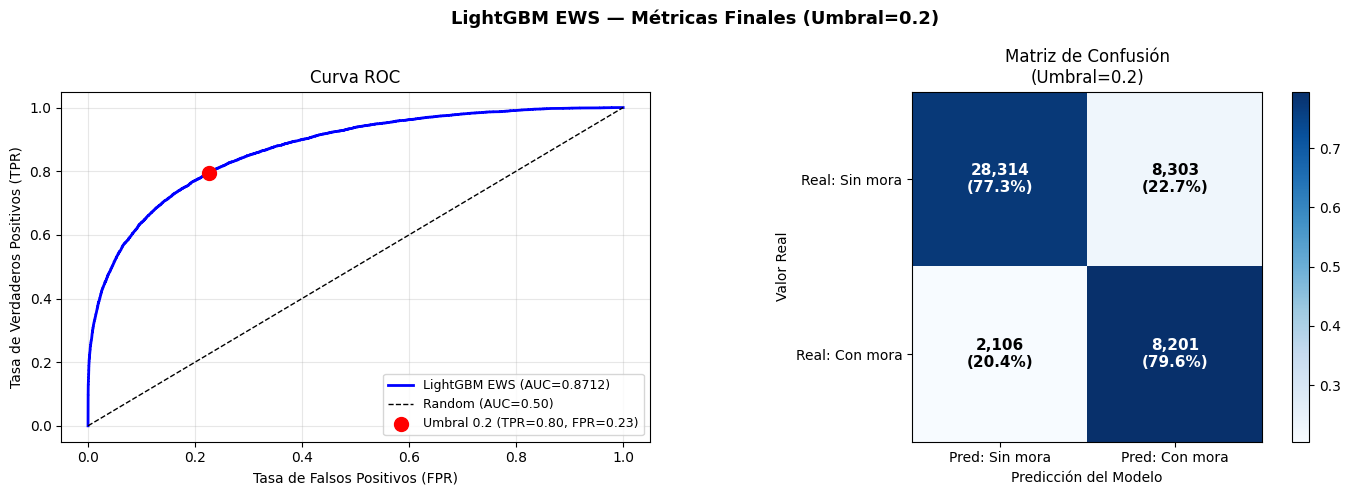

✅ Gráfica guardada


In [9]:
# ============================================================
# CELDA 9 — DOCUMENTACIÓN DEL UMBRAL DE DECISIÓN
# ============================================================
# Objetivo: documentar formalmente la justificación del
# umbral elegido y recalcular las métricas finales.
#
# Decisión: UMBRAL = 0.20
#
# Justificación económica:
# - Costo gestión preventiva  : $100 MXN por contacto
# - Pérdida por mora no detect: $89,854 MXN por crédito
# - Ratio mora/gestión        : 899x
# - Costo total umbral 0.20   : $190,062,824 MXN
# - Costo total umbral 0.50   : $471,169,868 MXN
# - Ahorro con umbral 0.20    : $281,107,044 MXN (59.7%)
#
# Justificación operativa:
# - Recall 79.6%: detecta ~8 de cada 10 clientes en mora
# - 35.2% de cartera recibe alerta: manejable operativamente
# - Balance entre capacidad de gestión y cobertura de riesgo
# ============================================================

print("=" * 60)
print("MÉTRICAS FINALES CON UMBRAL ÓPTIMO = 0.20")
print("=" * 60)

# ── Recalcular métricas con umbral 0.20 ──────────────────────
y_pred_final = (y_pred_proba >= UMBRAL_DECISION).astype(int)

auc_final      = roc_auc_score(y_test, y_pred_proba)
recall_final   = recall_score(y_test, y_pred_final)
precision_final= precision_score(y_test, y_pred_final)
f1_final       = f1_score(y_test, y_pred_final)
fpr_f, tpr_f, _= roc_curve(y_test, y_pred_proba)
ks_final       = np.max(tpr_f - fpr_f)

# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(
    y_test, y_pred_final
).ravel()

print(f"\n📊 Métricas con umbral {UMBRAL_DECISION}:")
print(f"   {'Métrica':<30} {'Valor':>10}")
print(f"   {'-'*42}")
print(f"   {'AUC-ROC':<30} {auc_final:>10.4f}")
print(f"   {'KS Statistic':<30} {ks_final:>10.4f}")
print(f"   {'Recall (Sensibilidad)':<30} {recall_final:>10.4f}")
print(f"   {'Precisión':<30} {precision_final:>10.4f}")
print(f"   {'F1-Score':<30} {f1_final:>10.4f}")

print(f"\n📊 Matriz de confusión:")
print(f"   {'':>20} Pred: No mora   Pred: Mora")
print(f"   Real: No mora    {tn:>10,}   {fp:>10,}")
print(f"   Real: Mora       {fn:>10,}   {tp:>10,}")

print(f"\n📊 Interpretación operativa:")
print(f"   Clientes en mora correctamente alertados : "
      f"{tp:>8,} ({recall_final:.1%})")
print(f"   Clientes en mora NO detectados           : "
      f"{fn:>8,} ({fn/(tp+fn):.1%})")
print(f"   Falsas alarmas (buenos con alerta)       : "
      f"{fp:>8,}")
print(f"   Total alertas generadas                  : "
      f"{tp+fp:>8,} ({(tp+fp)/len(y_test):.1%} cartera)")

# ── Actualizar registro en MLflow ─────────────────────────────
print(f"\n📝 Actualizando MLflow con umbral final...")

with mlflow.start_run(run_name='lightgbm_ews_umbral_optimo'):
    mlflow.log_param('umbral_decision',   UMBRAL_DECISION)
    mlflow.log_param('justificacion',
                     'costo_beneficio_economico')
    mlflow.log_param('c_gestion_mxn',    100)
    mlflow.log_param('c_mora_mxn',       89854)

    mlflow.log_metric('auc_test',        auc_final)
    mlflow.log_metric('ks_stat',         ks_final)
    mlflow.log_metric('recall_umbral_opt', recall_final)
    mlflow.log_metric('precision_umbral_opt', precision_final)
    mlflow.log_metric('f1_umbral_opt',   f1_final)
    mlflow.log_metric('n_alertas',       int(tp + fp))
    mlflow.log_metric('pct_cartera_alertada',
                      (tp + fp) / len(y_test))
    mlflow.log_metric('costo_total_mxn', 190_062_824)
    mlflow.log_metric('ahorro_vs_050',   281_107_044)

print(f"✅ Registro actualizado en MLflow")

# ── Visualización: curva ROC final ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'LightGBM EWS — Métricas Finales (Umbral={UMBRAL_DECISION})',
    fontsize=13, fontweight='bold'
)

# Curva ROC
ax1 = axes[0]
ax1.plot(fpr_f, tpr_f, 'b-', linewidth=2,
         label=f'LightGBM EWS (AUC={auc_final:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random (AUC=0.50)')

# Marcar el punto del umbral óptimo en la curva ROC
# Encontrar el punto más cercano al umbral 0.20
fpr_c, tpr_c, thresh_c = roc_curve(y_test, y_pred_proba)
idx_u = np.argmin(np.abs(thresh_c - UMBRAL_DECISION))
ax1.scatter(fpr_c[idx_u], tpr_c[idx_u],
            color='red', s=100, zorder=5,
            label=f'Umbral {UMBRAL_DECISION} '
                  f'(TPR={tpr_c[idx_u]:.2f}, '
                  f'FPR={fpr_c[idx_u]:.2f})')
ax1.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax1.set_title('Curva ROC')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Matriz de confusión visual
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred_final)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

im = ax2.imshow(cm_pct, interpolation='nearest',
                cmap='Blues')
plt.colorbar(im, ax=ax2)

clases = ['Sin mora (0)', 'Con mora (1)']
tick_marks = np.arange(len(clases))
ax2.set_xticks(tick_marks)
ax2.set_yticks(tick_marks)
ax2.set_xticklabels(['Pred: Sin mora', 'Pred: Con mora'])
ax2.set_yticklabels(['Real: Sin mora', 'Real: Con mora'])

# Agregar valores en la matriz
for i in range(2):
    for j in range(2):
        ax2.text(j, i,
                 f'{cm[i,j]:,}\n({cm_pct[i,j]:.1%})',
                 ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if cm_pct[i,j] > 0.5
                 else 'black')

ax2.set_title(f'Matriz de Confusión\n(Umbral={UMBRAL_DECISION})')
ax2.set_ylabel('Valor Real')
ax2.set_xlabel('Predicción del Modelo')

plt.tight_layout()
plt.savefig(f'{FIGS}/ews_metricas_finales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

In [10]:
# ============================================================
# CELDA 10 — ENTRENAMIENTO REGRESIÓN LOGÍSTICA
# ============================================================
# Objetivo: entrenar el modelo regulatorio complementario.
#
# ¿Por qué un Pipeline?
# Pipeline encadena transformaciones + modelo en un solo objeto:
#   Paso 1: StandardScaler → escala variables a media=0, std=1
#   Paso 2: LogisticRegression → entrena el modelo
#
# Ventaja: al predecir en producción, el escalado se aplica
# automáticamente — no hay riesgo de olvidar escalar.
#
# ¿Por qué escalar para Regresión Logística pero no para LightGBM?
# LightGBM usa árboles de decisión — solo le importan los
# rangos relativos, no los valores absolutos. La escala no
# afecta su funcionamiento.
# La Regresión Logística usa gradiente descendente — los
# coeficientes son sensibles a la magnitud de las variables.
# ============================================================

print("=" * 55)
print("ENTRENAMIENTO REGRESIÓN LOGÍSTICA — MODELO REGULATORIO")
print("=" * 55)

# ── Paso 1: Construir el Pipeline ────────────────────────────
# StandardScaler: transforma cada variable a media=0, std=1
# Esto hace que todas las variables tengan la misma escala
# y el modelo pueda comparar sus coeficientes directamente
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),           # Paso 1: escalar
    ('modelo', LogisticRegression(**LR_PARAMS))  # Paso 2: entrenar
])

# ── Paso 2: Validación cruzada ────────────────────────────────
print(f"\n[1/3] Validación cruzada {N_FOLDS} folds...")

auc_folds_lr = []

for fold, (idx_train, idx_val) in enumerate(
    skf.split(X_train, y_train), 1
):
    X_fold_train = X_train.iloc[idx_train]
    X_fold_val   = X_train.iloc[idx_val]
    y_fold_train = y_train.iloc[idx_train]
    y_fold_val   = y_train.iloc[idx_val]

    # El pipeline escala y entrena en un solo paso
    pipeline_lr.fit(X_fold_train, y_fold_train)

    y_pred_fold = pipeline_lr.predict_proba(
        X_fold_val
    )[:, 1]
    auc_fold = roc_auc_score(y_fold_val, y_pred_fold)
    auc_folds_lr.append(auc_fold)

    print(f"   Fold {fold}: AUC = {auc_fold:.4f}")

auc_cv_lr_mean = np.mean(auc_folds_lr)
auc_cv_lr_std  = np.std(auc_folds_lr)

print(f"\n   AUC CV promedio : {auc_cv_lr_mean:.4f}")
print(f"   AUC CV std      : {auc_cv_lr_std:.4f}")

# ── Paso 3: Entrenamiento final ───────────────────────────────
print(f"\n[2/3] Entrenamiento final...")

pipeline_lr.fit(X_train, y_train)

# Métricas en test
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_pred_clase_lr = (
    y_pred_proba_lr >= UMBRAL_DECISION
).astype(int)

auc_lr      = roc_auc_score(y_test, y_pred_proba_lr)
recall_lr   = recall_score(y_test, y_pred_clase_lr)
prec_lr     = precision_score(y_test, y_pred_clase_lr)
f1_lr       = f1_score(y_test, y_pred_clase_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
ks_lr       = np.max(tpr_lr - fpr_lr)

print(f"\n   📊 Métricas en test set (umbral={UMBRAL_DECISION}):")
print(f"   {'Métrica':<25} {'Valor':>10}")
print(f"   {'-'*37}")
print(f"   {'AUC-ROC':<25} {auc_lr:>10.4f}")
print(f"   {'KS Statistic':<25} {ks_lr:>10.4f}")
print(f"   {'Recall':<25} {recall_lr:>10.4f}")
print(f"   {'Precisión':<25} {prec_lr:>10.4f}")
print(f"   {'F1-Score':<25} {f1_lr:>10.4f}")
print(f"   {'AUC CV':<25} {auc_cv_lr_mean:>10.4f}")

# ── Paso 4: Coeficientes del modelo ──────────────────────────
# Esta es la ventaja regulatoria de la Regresión Logística:
# cada coeficiente indica cuánto contribuye cada variable
# al riesgo de mora — directamente interpretable
print(f"\n📊 Top 15 variables más importantes "
      f"(por coeficiente absoluto):")
print(f"   {'Variable':<35} {'Coeficiente':>12} "
      f"{'Dirección':>15}")
print(f"   {'-'*65}")

# Extraer coeficientes del modelo dentro del pipeline
coefs = pipeline_lr.named_steps['modelo'].coef_[0]
df_coefs = pd.DataFrame({
    'variable'    : X_train.columns,
    'coeficiente' : coefs,
    'abs_coef'    : np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

for _, row in df_coefs.head(15).iterrows():
    nombre = NOMBRES_LEGIBLES.get(
        row['variable'], row['variable']
    )
    direccion = "↑ aumenta mora" if row['coeficiente'] > 0 \
                else "↓ reduce mora"
    print(f"   {nombre:<35} {row['coeficiente']:>12.4f} "
          f"  {direccion}")

# ── Paso 5: Registrar en MLflow ───────────────────────────────
print(f"\n[3/3] Registrando en MLflow...")

if auc_lr >= AUC_MINIMO:
    with mlflow.start_run(run_name='logistic_regression_ews_v1'):
        mlflow.log_params(LR_PARAMS)
        mlflow.log_param('umbral_decision', UMBRAL_DECISION)
        mlflow.log_param('escalado', 'StandardScaler')

        mlflow.log_metric('auc_test',     auc_lr)
        mlflow.log_metric('ks_stat',      ks_lr)
        mlflow.log_metric('recall',       recall_lr)
        mlflow.log_metric('precision',    prec_lr)
        mlflow.log_metric('f1',           f1_lr)
        mlflow.log_metric('auc_cv_mean',  auc_cv_lr_mean)

        mlflow.sklearn.log_model(
            pipeline_lr,
            artifact_path         = 'logistic_regression_ews',
            registered_model_name = 'logistic_regression_ews'
        )

    print(f"   ✅ Modelo registrado: logistic_regression_ews")
else:
    print(f"   ❌ AUC {auc_lr:.4f} < {AUC_MINIMO} — "
          f"no registrado")

ENTRENAMIENTO REGRESIÓN LOGÍSTICA — MODELO REGULATORIO

[1/3] Validación cruzada 5 folds...
   Fold 1: AUC = 0.8156
   Fold 2: AUC = 0.8156
   Fold 3: AUC = 0.8178
   Fold 4: AUC = 0.8200
   Fold 5: AUC = 0.8152

   AUC CV promedio : 0.8169
   AUC CV std      : 0.0018

[2/3] Entrenamiento final...


2026/05/18 11:36:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



   📊 Métricas en test set (umbral=0.2):
   Métrica                        Valor
   -------------------------------------
   AUC-ROC                       0.8163
   KS Statistic                  0.4824
   Recall                        0.7165
   Precisión                     0.4586
   F1-Score                      0.5592
   AUC CV                        0.8169

📊 Top 15 variables más importantes (por coeficiente absoluto):
   Variable                             Coeficiente       Dirección
   -----------------------------------------------------------------
   Promedio DPD regulatorio                 -2.3317   ↓ reduce mora
   Máx. DPD regulatorio                      1.7420   ↑ aumenta mora
   % meses con DPD                           0.8237   ↑ aumenta mora
   % cuotas atrasadas                        0.4472   ↑ aumenta mora
   Total de cuotas                           0.4136   ↑ aumenta mora
   Precio del bien                          -0.3504   ↓ reduce mora
   Promedio DPD mensual  

2026/05/18 11:36:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'logistic_regression_ews' already exists. Creating a new version of this model...
Created version '3' of model 'logistic_regression_ews'.


   ✅ Modelo registrado: logistic_regression_ews


COMPARACIÓN DE MODELOS — LIGHTGBM vs REG. LOGÍSTICA

Métrica                       LightGBM   Reg. Logística   Diferencia
-------------------------------------------------------------------
   AUC-ROC                       0.8712           0.8163 +     0.0549
   KS                            0.5719           0.4824 +     0.0895
   Recall                        0.7957           0.7165 +     0.0792
   Precisión                     0.4969           0.4586 +     0.0384
   F1-Score                      0.6118           0.5592 +     0.0525
   AUC CV                        0.8683           0.8169 +     0.0514


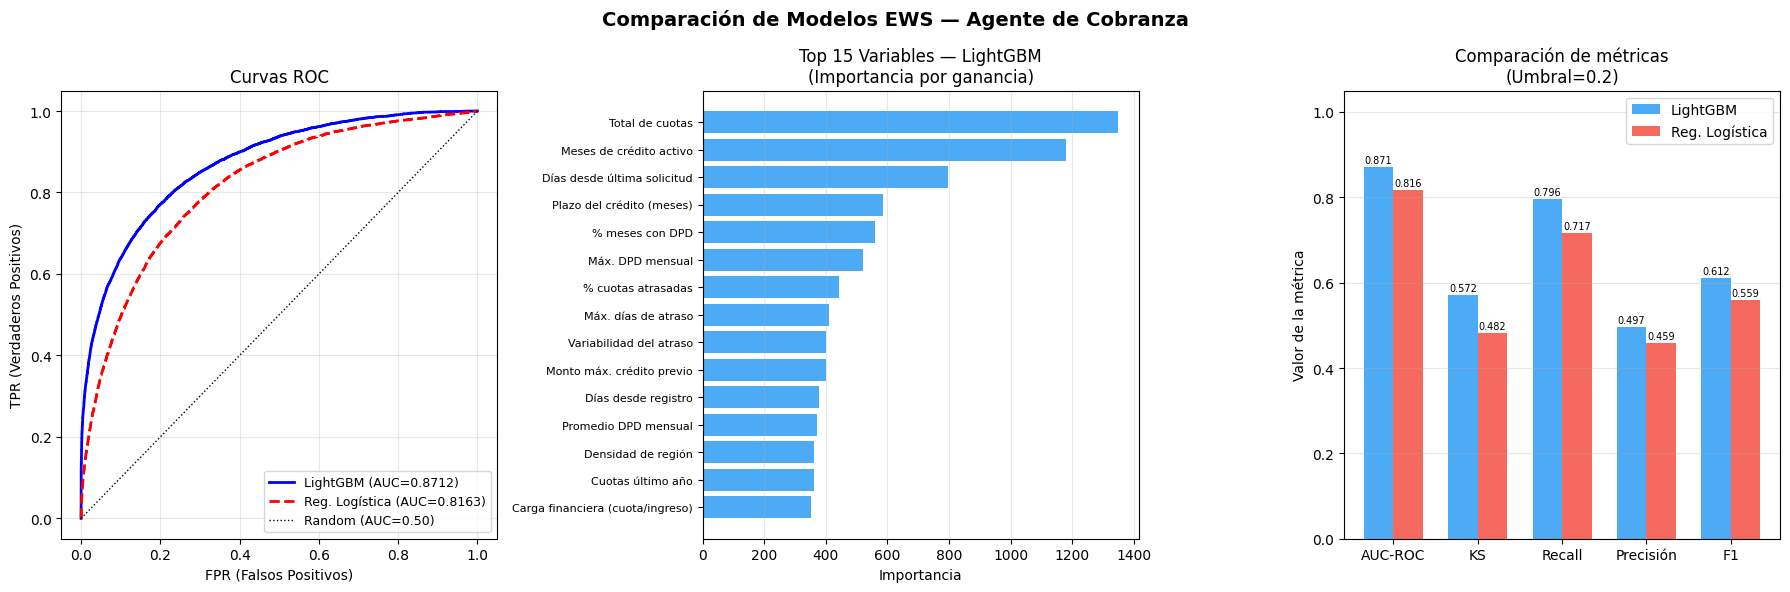

✅ Gráfica guardada

CONCLUSIÓN PARA EXPEDIENTE TÉCNICO

Modelo de producción  : LightGBM EWS
  AUC-ROC             : 0.8712
  KS Statistic        : 0.5719
  Recall (umbral 0.20): 79.6%
  Umbral de decisión  : 0.2
    Justificación     : análisis costo-beneficio económico
    Costo mora/gestión: 899x → favorecer recall alto

Modelo regulatorio    : Regresión Logística EWS
  AUC-ROC             : 0.8163
  KS Statistic        : 0.4824
  Uso                 : auditoría CNBV, validación regulatoria

Divergencia en variables DPD:
  LightGBM y Reg. Logística asignan importancias distintas
  a variables DPD por multicolinealidad entre
  max_dpd_def y mean_dpd_def. Documentado en expediente.
  Resolución: WoE si se requiere modelo completamente lineal.

Ambos modelos superan el gate AUC ≥ 0.7 y están
registrados en MLflow como versión 1.



In [11]:
# ============================================================
# CELDA 11 — COMPARACIÓN VISUAL: LIGHTGBM VS REG. LOGÍSTICA
# ============================================================
# Objetivo: visualizar la comparación entre ambos modelos
# para documentar en el expediente técnico regulatorio.
#
# Incluye:
# 1. Curvas ROC comparativas
# 2. Importancia de variables LightGBM (SHAP mean)
# 3. Tabla resumen de métricas
# ============================================================

print("=" * 55)
print("COMPARACIÓN DE MODELOS — LIGHTGBM vs REG. LOGÍSTICA")
print("=" * 55)

# ── Tabla resumen ─────────────────────────────────────────────
print(f"\n{'Métrica':<25} {'LightGBM':>12} "
      f"{'Reg. Logística':>16} {'Diferencia':>12}")
print("-" * 67)

metricas_comp = [
    ('AUC-ROC',    auc_final,    auc_lr),
    ('KS',         ks_final,     ks_lr),
    ('Recall',     recall_final, recall_lr),
    ('Precisión',  precision_final, prec_lr),
    ('F1-Score',   f1_final,     f1_lr),
    ('AUC CV',     auc_cv_mean,  auc_cv_lr_mean),
]

for nombre, val_lgbm, val_lr in metricas_comp:
    diff = val_lgbm - val_lr
    signo = "+" if diff > 0 else ""
    print(f"   {nombre:<23} {val_lgbm:>12.4f} "
          f"{val_lr:>16.4f} {signo}{diff:>11.4f}")

# ── Visualización ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Comparación de Modelos EWS — Agente de Cobranza',
    fontsize=14, fontweight='bold'
)

# Gráfica 1: Curvas ROC comparativas
ax1 = axes[0]
ax1.plot(fpr_f, tpr_f, 'b-', linewidth=2,
         label=f'LightGBM (AUC={auc_final:.4f})')
ax1.plot(fpr_lr, tpr_lr, 'r--', linewidth=2,
         label=f'Reg. Logística (AUC={auc_lr:.4f})')
ax1.plot([0,1], [0,1], 'k:', linewidth=1,
         label='Random (AUC=0.50)')
ax1.set_xlabel('FPR (Falsos Positivos)')
ax1.set_ylabel('TPR (Verdaderos Positivos)')
ax1.set_title('Curvas ROC')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Top 15 variables LightGBM por importancia
ax2 = axes[1]
importancias = pd.DataFrame({
    'variable'    : X_train.columns,
    'importancia' : modelo_lgbm.feature_importances_
}).sort_values('importancia', ascending=True).tail(15)

# Aplicar nombres legibles
importancias['nombre'] = importancias['variable'].map(
    lambda x: NOMBRES_LEGIBLES.get(x, x)
)

ax2.barh(importancias['nombre'],
         importancias['importancia'],
         color='#2196F3', alpha=0.8)
ax2.set_title('Top 15 Variables — LightGBM\n'
              '(Importancia por ganancia)')
ax2.set_xlabel('Importancia')
ax2.tick_params(axis='y', labelsize=8)
ax2.grid(True, alpha=0.3, axis='x')

# Gráfica 3: Comparación de métricas en barras
ax3 = axes[2]
nombres_met = ['AUC-ROC', 'KS', 'Recall',
               'Precisión', 'F1']
vals_lgbm   = [auc_final, ks_final, recall_final,
               precision_final, f1_final]
vals_lr     = [auc_lr, ks_lr, recall_lr,
               prec_lr, f1_lr]

x = np.arange(len(nombres_met))
w = 0.35

bars1 = ax3.bar(x - w/2, vals_lgbm, w,
                label='LightGBM', color='#2196F3',
                alpha=0.8)
bars2 = ax3.bar(x + w/2, vals_lr, w,
                label='Reg. Logística', color='#F44336',
                alpha=0.8)

# Agregar valores sobre las barras
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=7)

ax3.set_xticks(x)
ax3.set_xticklabels(nombres_met)
ax3.set_ylabel('Valor de la métrica')
ax3.set_title('Comparación de métricas\n'
              f'(Umbral={UMBRAL_DECISION})')
ax3.legend()
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGS}/ews_comparacion_modelos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

# ── Conclusión para el expediente técnico ─────────────────────
print(f"\n{'='*55}")
print("CONCLUSIÓN PARA EXPEDIENTE TÉCNICO")
print(f"{'='*55}")
print(f"""
Modelo de producción  : LightGBM EWS
  AUC-ROC             : {auc_final:.4f}
  KS Statistic        : {ks_final:.4f}
  Recall (umbral 0.20): {recall_final:.1%}
  Umbral de decisión  : {UMBRAL_DECISION}
    Justificación     : análisis costo-beneficio económico
    Costo mora/gestión: 899x → favorecer recall alto

Modelo regulatorio    : Regresión Logística EWS
  AUC-ROC             : {auc_lr:.4f}
  KS Statistic        : {ks_lr:.4f}
  Uso                 : auditoría CNBV, validación regulatoria

Divergencia en variables DPD:
  LightGBM y Reg. Logística asignan importancias distintas
  a variables DPD por multicolinealidad entre
  max_dpd_def y mean_dpd_def. Documentado en expediente.
  Resolución: WoE si se requiere modelo completamente lineal.

Ambos modelos superan el gate AUC ≥ {AUC_MINIMO} y están
registrados en MLflow como versión 1.
""")

In [12]:
# ============================================================
# CELDA 11b — ANÁLISIS VIF Y SELECCIÓN DE VARIABLES
# ============================================================
# Objetivo: detectar y resolver multicolinealidad en la
# Regresión Logística para obtener coeficientes regulatoriamente
# interpretables.
#
# ¿Qué es VIF?
# Variance Inflation Factor — mide cuánto se infla la varianza
# de cada coeficiente por la correlación con otras variables.
#
# Interpretación:
#   VIF 1     → sin multicolinealidad
#   VIF 1-5   → moderada, aceptable
#   VIF 5-10  → alta, considerar eliminar
#   VIF > 10  → muy alta, eliminar
#
# Método: eliminación iterativa
# 1. Calcular VIF de todas las variables
# 2. Eliminar la variable con VIF más alto (si > umbral)
# 3. Repetir hasta que todas tengan VIF aceptable
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

VIF_UMBRAL = 10   # Umbral máximo aceptable de VIF

print("=" * 60)
print("ANÁLISIS VIF — DETECCIÓN DE MULTICOLINEALIDAD")
print("=" * 60)
print(f"Umbral VIF máximo aceptable: {VIF_UMBRAL}")

# ── Paso 1: Calcular VIF inicial ──────────────────────────────
# Usamos X_train escalado para que los VIF sean comparables
scaler_vif = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_vif.fit_transform(X_train),
    columns=X_train.columns
)

def calcular_vif(df):
    """Calcula VIF para todas las columnas del DataFrame."""
    vif_data = pd.DataFrame()
    vif_data['variable'] = df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    vif_data['nombre_legible'] = vif_data['variable'].map(
        lambda x: NOMBRES_LEGIBLES.get(x, x)
    )
    return vif_data.sort_values('VIF', ascending=False)

# VIF inicial
print("\n📊 VIF inicial (top 20 variables):")
print(f"   {'Variable':<35} {'VIF':>8}")
print(f"   {'-'*45}")

vif_inicial = calcular_vif(X_train_scaled)
for _, row in vif_inicial.head(20).iterrows():
    alerta = " ⚠️" if row['VIF'] > VIF_UMBRAL else ""
    print(f"   {row['nombre_legible']:<35} "
          f"{row['VIF']:>8.2f}{alerta}")

n_problematicas = (vif_inicial['VIF'] > VIF_UMBRAL).sum()
print(f"\n   Variables con VIF > {VIF_UMBRAL}: {n_problematicas}")

# ── Paso 2: Eliminación iterativa ─────────────────────────────
print(f"\n🔄 Eliminación iterativa de variables con VIF > "
      f"{VIF_UMBRAL}...")

cols_actuales    = list(X_train.columns)
variables_eliminadas = []
iteracion        = 0

while True:
    iteracion += 1

    # Escalar con las columnas actuales
    X_iter_scaled = pd.DataFrame(
        StandardScaler().fit_transform(
            X_train[cols_actuales]
        ),
        columns=cols_actuales
    )

    # Calcular VIF
    vif_iter = calcular_vif(X_iter_scaled)
    max_vif  = vif_iter['VIF'].max()

    if max_vif <= VIF_UMBRAL:
        print(f"   ✅ Iteración {iteracion}: "
              f"todas las variables tienen VIF ≤ {VIF_UMBRAL}")
        break

    # Eliminar la variable con VIF más alto
    var_eliminar = vif_iter.iloc[0]['variable']
    nombre_elim  = vif_iter.iloc[0]['nombre_legible']
    vif_elim     = vif_iter.iloc[0]['VIF']

    cols_actuales.remove(var_eliminar)
    variables_eliminadas.append({
        'variable': var_eliminar,
        'nombre'  : nombre_elim,
        'vif'     : vif_elim,
        'iteracion': iteracion
    })

    print(f"   Iteración {iteracion:>2}: eliminando "
          f"'{nombre_elim}' (VIF={vif_elim:.2f})")

# ── Paso 3: Resumen de variables eliminadas ───────────────────
print(f"\n📊 Variables eliminadas por multicolinealidad:")
print(f"   {'Variable':<35} {'VIF':>8} {'Iteración':>10}")
print(f"   {'-'*55}")
for v in variables_eliminadas:
    print(f"   {v['nombre']:<35} {v['vif']:>8.2f} "
          f"{v['iteracion']:>10}")

print(f"\n   Variables originales  : {len(X_train.columns)}")
print(f"   Variables eliminadas  : {len(variables_eliminadas)}")
print(f"   Variables finales     : {len(cols_actuales)}")

# ── Paso 4: VIF final ─────────────────────────────────────────
print(f"\n📊 VIF final (todas las variables restantes):")
print(f"   {'Variable':<35} {'VIF':>8}")
print(f"   {'-'*45}")

X_final_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_train[cols_actuales]),
    columns=cols_actuales
)
vif_final = calcular_vif(X_final_scaled)

for _, row in vif_final.iterrows():
    print(f"   {row['nombre_legible']:<35} {row['VIF']:>8.2f}")

max_vif_final = vif_final['VIF'].max()
print(f"\n   VIF máximo final: {max_vif_final:.2f} "
      f"({'✅ aceptable' if max_vif_final <= VIF_UMBRAL else '❌ revisar'})")

# ── Paso 5: Re-entrenar Regresión Logística ───────────────────
print(f"\n🔄 Re-entrenando Regresión Logística sin "
      f"variables multicolineales...")

# Dataset con variables seleccionadas
X_train_vif = X_train[cols_actuales]
X_test_vif  = X_test[cols_actuales]

# Pipeline con variables limpias
pipeline_lr_vif = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(**LR_PARAMS))
])

pipeline_lr_vif.fit(X_train_vif, y_train)

# Métricas
y_pred_proba_lr_vif = pipeline_lr_vif.predict_proba(
    X_test_vif
)[:, 1]
y_pred_clase_lr_vif = (
    y_pred_proba_lr_vif >= UMBRAL_DECISION
).astype(int)

auc_lr_vif    = roc_auc_score(y_test, y_pred_proba_lr_vif)
recall_lr_vif = recall_score(y_test, y_pred_clase_lr_vif)
prec_lr_vif   = precision_score(y_test, y_pred_clase_lr_vif)
f1_lr_vif     = f1_score(y_test, y_pred_clase_lr_vif)
fpr_lr_vif, tpr_lr_vif, _ = roc_curve(
    y_test, y_pred_proba_lr_vif
)
ks_lr_vif = np.max(tpr_lr_vif - fpr_lr_vif)

print(f"\n📊 Comparación antes/después de eliminar VIF alto:")
print(f"   {'Métrica':<20} {'Con multicol.':>15} "
      f"{'Sin multicol.':>15} {'Cambio':>10}")
print(f"   {'-'*62}")

for nombre, antes, despues in [
    ('AUC-ROC',   auc_lr,    auc_lr_vif),
    ('KS',        ks_lr,     ks_lr_vif),
    ('Recall',    recall_lr, recall_lr_vif),
    ('Precisión', prec_lr,   prec_lr_vif),
    ('F1-Score',  f1_lr,     f1_lr_vif),
]:
    cambio = despues - antes
    signo  = "+" if cambio > 0 else ""
    print(f"   {nombre:<20} {antes:>15.4f} "
          f"{despues:>15.4f} {signo}{cambio:>9.4f}")

# ── Paso 6: Coeficientes limpios ──────────────────────────────
print(f"\n📊 Coeficientes limpios (sin multicolinealidad):")
print(f"   {'Variable':<35} {'Coeficiente':>12} "
      f"{'Dirección':>16}")
print(f"   {'-'*65}")

coefs_vif = pipeline_lr_vif.named_steps['modelo'].coef_[0]
df_coefs_vif = pd.DataFrame({
    'variable'    : cols_actuales,
    'coeficiente' : coefs_vif,
    'abs_coef'    : np.abs(coefs_vif)
}).sort_values('abs_coef', ascending=False)

for _, row in df_coefs_vif.head(15).iterrows():
    nombre    = NOMBRES_LEGIBLES.get(
        row['variable'], row['variable']
    )
    direccion = "↑ aumenta mora" if row['coeficiente'] > 0 \
                else "↓ reduce mora"
    print(f"   {nombre:<35} {row['coeficiente']:>12.4f} "
          f"  {direccion}")

# ── Paso 7: Registrar modelo limpio en MLflow ─────────────────
print(f"\n📝 Registrando modelo limpio en MLflow...")

with mlflow.start_run(run_name='logistic_regression_ews_vif_v2'):
    mlflow.log_param('umbral_decision',    UMBRAL_DECISION)
    mlflow.log_param('vif_umbral',         VIF_UMBRAL)
    mlflow.log_param('vars_eliminadas',    len(variables_eliminadas))
    mlflow.log_param('vars_finales',       len(cols_actuales))
    mlflow.log_params(LR_PARAMS)

    mlflow.log_metric('auc_test',          auc_lr_vif)
    mlflow.log_metric('ks_stat',           ks_lr_vif)
    mlflow.log_metric('recall',            recall_lr_vif)
    mlflow.log_metric('precision',         prec_lr_vif)
    mlflow.log_metric('f1',               f1_lr_vif)

    mlflow.sklearn.log_model(
        pipeline_lr_vif,
        artifact_path         = 'logistic_regression_ews_vif',
        registered_model_name = 'logistic_regression_ews_vif'
    )

print(f"✅ Modelo limpio registrado: logistic_regression_ews_vif")

ANÁLISIS VIF — DETECCIÓN DE MULTICOLINEALIDAD
Umbral VIF máximo aceptable: 10

📊 VIF inicial (top 20 variables):
   Variable                                 VIF
   ---------------------------------------------
   Edad (años)                         168796.58 ⚠️
   Edad (días)                         168795.93 ⚠️
   % pagos parciales                    5113.08 ⚠️
   % pagos completos                    5111.42 ⚠️
   N° solicitudes previas                171.39 ⚠️
   Monto del crédito                      52.44 ⚠️
   N° créditos aprobados prev.            50.60 ⚠️
   Precio del bien                        39.75 ⚠️
   N° créditos rechazados prev.           34.94 ⚠️
   N° créditos cancelados prev.           29.09 ⚠️
   Monto prom. crédito previo             25.05 ⚠️
   Miembros del hogar                     23.55 ⚠️
   Monto prom. solicitud previa           21.83 ⚠️
   Variabilidad del atraso                17.89 ⚠️
   Número de hijos                        17.05 ⚠️
   Máx. DPD regulatorio

2026/05/18 11:55:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 Comparación antes/después de eliminar VIF alto:
   Métrica                Con multicol.   Sin multicol.     Cambio
   --------------------------------------------------------------
   AUC-ROC                       0.8163          0.8106   -0.0057
   KS                            0.4824          0.4713   -0.0110
   Recall                        0.7165          0.7144   -0.0021
   Precisión                     0.4586          0.4488   -0.0098
   F1-Score                      0.5592          0.5512   -0.0080

📊 Coeficientes limpios (sin multicolinealidad):
   Variable                             Coeficiente        Dirección
   -----------------------------------------------------------------
   % meses con DPD                           0.8789   ↑ aumenta mora
   % cuotas atrasadas                        0.4703   ↑ aumenta mora
   Promedio DPD mensual                     -0.4260   ↓ reduce mora
   Total de cuotas                           0.4063   ↑ aumenta mora
   % pagos completos    

2026/05/18 11:55:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Modelo limpio registrado: logistic_regression_ews_vif


Registered model 'logistic_regression_ews_vif' already exists. Creating a new version of this model...
Created version '2' of model 'logistic_regression_ews_vif'.


ANÁLISIS SHAP — LIGHTGBM EWS

[1/4] Calculando valores SHAP...
      (puede tardar 1-2 minutos)
      ✅ SHAP calculado para 2,000 muestras
      Shape de valores SHAP: (2000, 52)

[2/4] Generando Summary Plot...


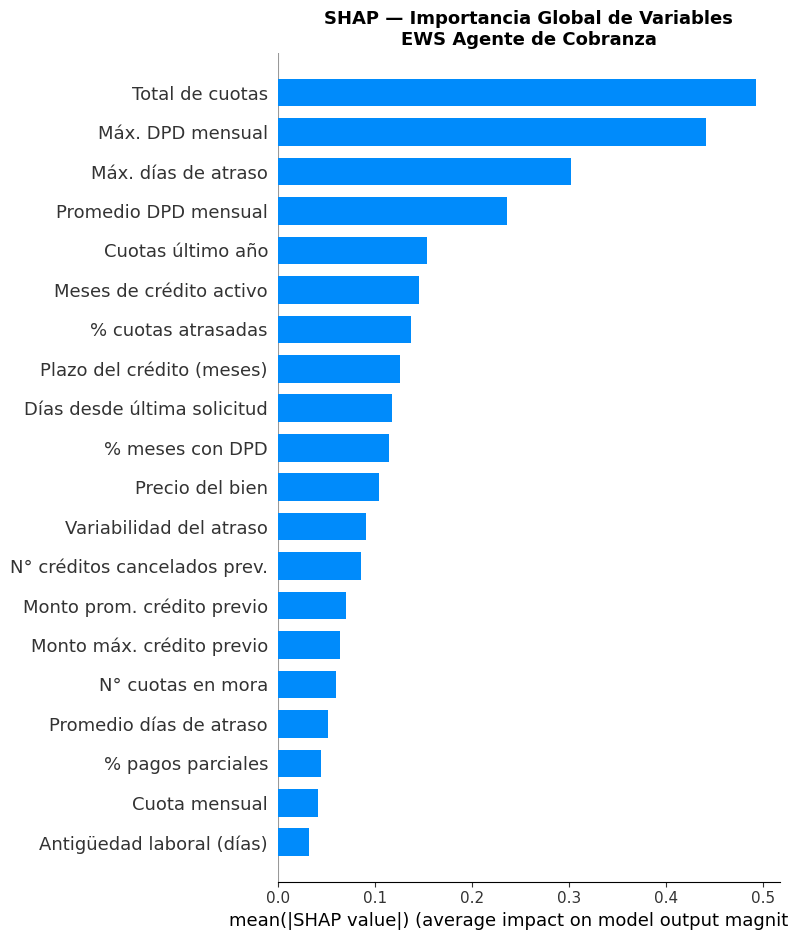

      ✅ Summary plot guardado

[3/4] Generando Beeswarm Plot...


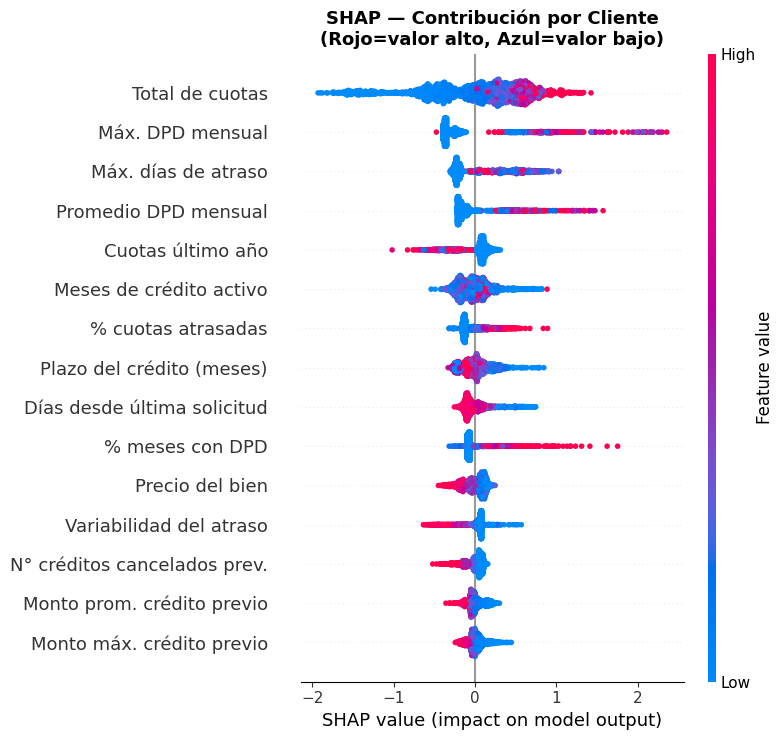

      ✅ Beeswarm plot guardado

[4/4] Generando explicación individual...

      Cliente seleccionado:
      Probabilidad de mora : 99.6%
      Clasificación        : CON MORA

      Top 10 variables que explican esta predicción:
      Variable                             Contribución      Valor       Dirección
      ---------------------------------------------------------------------------
      Máx. DPD mensual                          +2.0592       7.00  ↑ aumenta mora
      Promedio DPD mensual                      +1.2483       0.54  ↑ aumenta mora
      Variabilidad del atraso                   +0.5685       0.00  ↑ aumenta mora
      % meses con DPD 30+                       +0.4036       0.08  ↑ aumenta mora
      % meses con DPD                           +0.3722       0.08  ↑ aumenta mora
      Promedio días de atraso                   +0.3578       0.00  ↑ aumenta mora
      Máx. DPD regulatorio                      +0.3149       7.00  ↑ aumenta mora
      Meses de crédito a

In [13]:
# ============================================================
# CELDA 12 — ANÁLISIS SHAP PARA LIGHTGBM EWS
# ============================================================
# Objetivo: calcular valores SHAP para explicabilidad del
# modelo LightGBM a nivel individual y global.
#
# SHAP (SHapley Additive exPlanations) calcula la contribución
# de cada variable a cada predicción individual.
#
# Salidas:
# 1. Summary plot  → importancia global con distribución
# 2. Beeswarm plot → relación entre valor y contribución
# 3. Ejemplo individual → explicación de un cliente en riesgo
# 4. Guardar valores SHAP para el dashboard
# ============================================================

print("=" * 55)
print("ANÁLISIS SHAP — LIGHTGBM EWS")
print("=" * 55)

# ── Paso 1: Calcular valores SHAP ────────────────────────────
# TreeExplainer es el método optimizado para modelos de árboles
# Es mucho más rápido que el Explainer genérico
print("\n[1/4] Calculando valores SHAP...")
print("      (puede tardar 1-2 minutos)")

explainer   = shap.TreeExplainer(modelo_lgbm)

# Calculamos SHAP sobre una muestra del test para velocidad
# 2,000 muestras es suficiente para análisis global confiable
np.random.seed(RANDOM_SEED)
idx_muestra  = np.random.choice(
    len(X_test), size=2000, replace=False
)
X_muestra    = X_test.iloc[idx_muestra]
y_muestra    = y_test.iloc[idx_muestra]

shap_values  = explainer.shap_values(X_muestra)

# shap_values puede ser lista o array según la versión de SHAP
# Para clasificación binaria tomamos los valores de clase 1 (mora)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # Clase 1 = mora
else:
    shap_vals = shap_values

print(f"      ✅ SHAP calculado para {len(X_muestra):,} muestras")
print(f"      Shape de valores SHAP: {shap_vals.shape}")

# ── Paso 2: Renombrar columnas para visualización ────────────
# Aplicamos NOMBRES_LEGIBLES solo para las gráficas
X_muestra_leg = X_muestra.copy()
X_muestra_leg.columns = [
    NOMBRES_LEGIBLES.get(c, c) for c in X_muestra.columns
]

# ── Paso 3: Summary Plot — importancia global ─────────────────
# Muestra las variables ordenadas por importancia SHAP promedio
# El color indica el valor de la variable (rojo=alto, azul=bajo)
# La posición horizontal indica la dirección del efecto
print("\n[2/4] Generando Summary Plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_muestra_leg,
    plot_type = 'bar',      # Barras de importancia global
    show      = False,
    max_display = 20        # Top 20 variables
)
plt.title('SHAP — Importancia Global de Variables\n'
          'EWS Agente de Cobranza',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGS}/shap_summary_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("      ✅ Summary plot guardado")

# ── Paso 4: Beeswarm Plot — valor vs contribución ────────────
# Cada punto es un cliente — la posición horizontal indica
# cuánto contribuye esa variable a la predicción de mora.
# El color indica el valor de la variable.
# Rojo = valor alto de la variable
# Azul = valor bajo de la variable
print("\n[3/4] Generando Beeswarm Plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_muestra_leg,
    plot_type   = 'dot',    # Beeswarm — un punto por cliente
    show        = False,
    max_display = 15
)
plt.title('SHAP — Contribución por Cliente\n'
          '(Rojo=valor alto, Azul=valor bajo)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGS}/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("      ✅ Beeswarm plot guardado")

# ── Paso 5: Explicación individual ───────────────────────────
# Seleccionamos el cliente con mayor probabilidad de mora
# para mostrar cómo se explica una predicción individual
print("\n[4/4] Generando explicación individual...")

# Cliente con mayor probabilidad de mora en la muestra
y_pred_muestra = modelo_lgbm.predict_proba(X_muestra)[:, 1]
idx_alto_riesgo = np.argmax(y_pred_muestra)
prob_mora       = y_pred_muestra[idx_alto_riesgo]

print(f"\n      Cliente seleccionado:")
print(f"      Probabilidad de mora : {prob_mora:.1%}")
print(f"      Clasificación        : "
      f"{'CON MORA' if prob_mora >= UMBRAL_DECISION else 'SIN MORA'}")

# Top 10 variables más influyentes para este cliente
shap_cliente   = shap_vals[idx_alto_riesgo]
df_shap_ind    = pd.DataFrame({
    'variable'    : X_muestra.columns,
    'shap_value'  : shap_cliente,
    'valor_real'  : X_muestra.iloc[idx_alto_riesgo].values,
    'abs_shap'    : np.abs(shap_cliente)
}).sort_values('abs_shap', ascending=False)

print(f"\n      Top 10 variables que explican esta predicción:")
print(f"      {'Variable':<35} {'Contribución':>13} "
      f"{'Valor':>10} {'Dirección':>15}")
print(f"      {'-'*75}")

for _, row in df_shap_ind.head(10).iterrows():
    nombre    = NOMBRES_LEGIBLES.get(
        row['variable'], row['variable']
    )
    direccion = "↑ aumenta mora" if row['shap_value'] > 0 \
                else "↓ reduce mora"
    print(f"      {nombre:<35} {row['shap_value']:>+13.4f} "
          f"{row['valor_real']:>10.2f} {direccion:>15}")

# ── Guardar valores SHAP para el dashboard ───────────────────
# El dashboard del Agente de Cobranza usará estos valores
# para explicar cada predicción en tiempo real
import joblib

shap_data = {
    'explainer'    : explainer,
    'feature_names': list(X_train.columns),
    'nombres_legibles': NOMBRES_LEGIBLES
}
joblib.dump(
    shap_data,
    f'{BASE}/dashboard/models/shap_ews_explainer.pkl'
)
print(f"\n      ✅ SHAP explainer guardado en dashboard/models/")

# ── Resumen SHAP global ───────────────────────────────────────
print(f"\n{'='*55}")
print("TOP 15 VARIABLES POR IMPORTANCIA SHAP GLOBAL")
print(f"{'='*55}")
print(f"{'Variable':<35} {'SHAP medio':>12}")
print(f"{'-'*49}")

shap_global = pd.DataFrame({
    'variable'  : X_muestra.columns,
    'shap_medio': np.abs(shap_vals).mean(axis=0)
}).sort_values('shap_medio', ascending=False)

for _, row in shap_global.head(15).iterrows():
    nombre = NOMBRES_LEGIBLES.get(
        row['variable'], row['variable']
      
    )
    print(f"   {nombre:<35} {row['shap_medio']:>12.4f}")

In [14]:
# ============================================================
# CELDA 13 — GUARDAR MODELO EWS PARA EL DASHBOARD
# ============================================================
# Objetivo: persistir el modelo LightGBM y su metadata
# en dashboard/models/ para uso en producción.
#
# Se guardan tres artefactos:
# 1. modelo_ews.pkl     — el modelo LightGBM entrenado
# 2. ews_metadata.pkl  — metadata del modelo (métricas,
#                        umbral, features, nombres legibles)
# 3. shap_ews_explainer.pkl — ya guardado en celda 12
# ============================================================

import joblib
from datetime import datetime

print("=" * 55)
print("GUARDANDO MODELO EWS PARA PRODUCCIÓN")
print("=" * 55)

MODELS_PATH = f'{BASE}/dashboard/models'

# ── 1. Guardar modelo LightGBM ───────────────────────────────
ruta_modelo = f'{MODELS_PATH}/modelo_ews.pkl'
joblib.dump(modelo_lgbm, ruta_modelo)
print(f"\n✅ Modelo LightGBM guardado:")
print(f"   {ruta_modelo}")

# ── 2. Guardar metadata del modelo ───────────────────────────
# La metadata permite que el dashboard muestre información
# del modelo sin necesidad de cargarlo completo
metadata_ews = {
    # Identificación
    'nombre'          : 'lightgbm_ews',
    'version'         : '1.0',
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d'),
    'descripcion'     : 'Early Warning System — Agente de Cobranza',

    # Datos de entrenamiento
    'n_clientes_train': len(X_train),
    'n_clientes_test' : len(X_test),
    'n_features'      : X_train.shape[1],
    'feature_names'   : list(X_train.columns),

    # Parámetros del modelo
    'umbral_decision' : UMBRAL_DECISION,
    'umbral_mora_dias': 5,
    'n_arboles'       : modelo_lgbm.best_iteration_,

    # Métricas de evaluación
    'metricas': {
        'auc_roc'   : round(auc_final, 4),
        'ks'        : round(ks_final, 4),
        'recall'    : round(recall_final, 4),
        'precision' : round(precision_final, 4),
        'f1'        : round(f1_final, 4),
        'auc_cv'    : round(auc_cv_mean, 4),
    },

    # Análisis costo-beneficio
    'costo_beneficio': {
        'c_gestion_mxn'  : 100,
        'c_mora_mxn'     : 89_854,
        'costo_total_mxn': 190_062_824,
        'ahorro_vs_050'  : 281_107_044,
        'pct_ahorro'     : 59.7,
    },

    # Top 10 variables por SHAP
    'top_variables_shap': shap_global.head(10)[
        ['variable', 'shap_medio']
    ].to_dict('records'),

    # Nombres legibles para el dashboard
    'nombres_legibles': NOMBRES_LEGIBLES,

    # Información del target
    'target_col'      : TARGET_COL,
    'tasa_mora_train' : round(y_train.mean(), 4),
    'tasa_mora_test'  : round(y_test.mean(), 4),
}

ruta_metadata = f'{MODELS_PATH}/ews_metadata.pkl'
joblib.dump(metadata_ews, ruta_metadata)
print(f"\n✅ Metadata guardada:")
print(f"   {ruta_metadata}")

# ── 3. Verificar archivos guardados ──────────────────────────
import os
print(f"\n📁 Contenido de dashboard/models/:")
for archivo in sorted(os.listdir(MODELS_PATH)):
    ruta    = os.path.join(MODELS_PATH, archivo)
    tamanio = os.path.getsize(ruta) / 1024 / 1024
    print(f"   {archivo:<40} {tamanio:>8.2f} MB")

# ── 4. Resumen final del Bloque 2 ────────────────────────────
print(f"\n{'='*55}")
print("RESUMEN FINAL — MODELADO EWS COMPLETADO")
print(f"{'='*55}")
print(f"""
Modelos entrenados y registrados en MLflow:
  1. lightgbm_ews          AUC={auc_final:.4f}  KS={ks_final:.4f}
     Recall={recall_final:.1%}  Umbral={UMBRAL_DECISION}
     → Modelo de PRODUCCIÓN

  2. logistic_regression_ews      AUC={auc_lr:.4f}
     → Modelo REGULATORIO (con multicolinealidad documentada)

  3. logistic_regression_ews_vif  AUC={auc_lr_vif:.4f}
     → Modelo REGULATORIO LIMPIO (VIF ≤ 10, 43 variables)

Artefactos guardados en dashboard/models/:
  ✅ modelo_ews.pkl
  ✅ ews_metadata.pkl
  ✅ shap_ews_explainer.pkl

Siguiente paso — Bloque 3:
  RAG con ChromaDB + Claude API
  → Generar estrategias de cobranza personalizadas
""")

GUARDANDO MODELO EWS PARA PRODUCCIÓN

✅ Modelo LightGBM guardado:
   C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml/dashboard/models/modelo_ews.pkl

✅ Metadata guardada:
   C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml/dashboard/models/ews_metadata.pkl

📁 Contenido de dashboard/models/:
   ews_metadata.pkl                             0.00 MB
   model.pkl                                    0.96 MB
   modelo_ews.pkl                               1.67 MB
   scorecard_woe.pkl                            0.03 MB
   shap_ews_explainer.pkl                       4.45 MB

RESUMEN FINAL — MODELADO EWS COMPLETADO

Modelos entrenados y registrados en MLflow:
  1. lightgbm_ews          AUC=0.8712  KS=0.5719
     Recall=79.6%  Umbral=0.2
     → Modelo de PRODUCCIÓN

  2. logistic_regression_ews      AUC=0.8163
     → Modelo REGULATORIO (con multicolinealidad documentada)

  3. logistic_regression_ews_vif  AUC=0.8106
     → Modelo REGULATORIO LIMPIO (VIF ≤ 10, 43 var